In [5]:
import copernicusmarine
import os

input_dir = "inputs_demo"
os.makedirs(input_dir, exist_ok=True)

/home/shrey/.local/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
bbox = {
    "minimum_longitude": 45.0,
    "maximum_longitude": 105.0,
    "minimum_latitude": 5.0,
    "maximum_latitude": 30.0,
    "start_datetime": "2021-01-01 00:00:00",
    "end_datetime": "2021-01-31 23:59:59",
    "output_directory": input_dir,
    "force_download": True
}

In [6]:
# SST --> 010_011

copernicusmarine.subset(
    dataset_id="METOFFICE-GLO-SST-L4-REP-OBS-SST",
    variables=["analysed_sst"],
    output_filename="01_jan_sst.nc",
    **bbox
)

WARNING - 2026-09-10T14:00:34Z - 'force_download' has been deprecated.
INFO - 2026-09-10T14:00:36Z - Selected dataset version: "202003"
INFO - 2026-09-10T14:00:36Z - Selected dataset part: "default"
INFO - 2026-09-10T14:00:43Z - Total size of the download: 1.16 MB.


ResponseSubset(file_path=PosixPath('inputs_demo/01_jan_sst.nc'), output_directory=PosixPath('inputs_demo'), filename='01_jan_sst.nc', file_size=1.158038167938931, data_transfer_size=32.01758778625954, variables=['analysed_sst'], coordinates_extent=[GeographicalExtent(minimum=45.025001525878906, maximum=104.9749984741211, unit='degrees_east', coordinate_id='longitude'), GeographicalExtent(minimum=5.025000095367432, maximum=29.975000381469727, unit='degrees_north', coordinate_id='latitude'), TimeExtent(minimum='2021-01-01T00:00:00+00:00', maximum='2021-01-01T00:00:00+00:00', unit='iso8601', coordinate_id='time')], status='000', message='The request was successful.', file_status='DOWNLOADED', file_names=None)

In [7]:
# SSS 015_013

copernicusmarine.subset(
    dataset_id="cmems_obs-mob_glo_phy-sss_my_multi_P1D",
    variables=["sos"],
    output_filename="02_jan_sss.nc",
    **bbox
)

WARNING - 2026-09-10T14:01:06Z - 'force_download' has been deprecated.
INFO - 2026-09-10T14:01:09Z - Selected dataset version: "202311"
INFO - 2026-09-10T14:01:09Z - Selected dataset part: "default"
INFO - 2026-09-10T14:01:14Z - Total size of the download: 388.52 KB.


ResponseSubset(file_path=PosixPath('inputs_demo/02_jan_sss.nc'), output_directory=PosixPath('inputs_demo'), filename='02_jan_sss.nc', file_size=0.379412213740458, data_transfer_size=16.00879389312977, variables=['sos'], coordinates_extent=[GeographicalExtent(minimum=45.0625, maximum=104.9375, unit='degrees_east', coordinate_id='longitude'), GeographicalExtent(minimum=5.0625, maximum=29.9375, unit='degrees_north', coordinate_id='latitude'), TimeExtent(minimum='2021-01-01T00:00:00+00:00', maximum='2021-01-01T00:00:00+00:00', unit='iso8601', coordinate_id='time'), GeographicalExtent(minimum=0.0, maximum=0.0, unit='m', coordinate_id='depth')], status='000', message='The request was successful.', file_status='DOWNLOADED', file_names=None)

In [7]:
# SSH 008_057

copernicusmarine.subset(
    dataset_id="cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D",
    variables=["sla"],
    output_filename="03_ssh.nc",
    **bbox
)


WARNING - 2026-09-13T09:46:59Z - 'force_download' has been deprecated.
INFO - 2026-09-13T09:47:02Z - Selected dataset version: "202411"
INFO - 2026-09-13T09:47:02Z - Selected dataset part: "default"
INFO - 2026-09-13T09:47:07Z - Total size of the download: 388.52 KB.


ResponseSubset(file_path=PosixPath('inputs_demo/03_ssh.nc'), output_directory=PosixPath('inputs_demo'), filename='03_ssh.nc', file_size=0.379412213740458, data_transfer_size=8.004396946564885, variables=['sla'], coordinates_extent=[GeographicalExtent(minimum=45.0625, maximum=104.9375, unit='degrees_east', coordinate_id='longitude'), GeographicalExtent(minimum=5.0625, maximum=29.9375, unit='degrees_north', coordinate_id='latitude'), TimeExtent(minimum='2021-01-01T00:00:00+00:00', maximum='2021-01-01T00:00:00+00:00', unit='iso8601', coordinate_id='time')], status='000', message='The request was successful.', file_status='DOWNLOADED', file_names=None)

In [ ]:
# Winds 012_006
"""copernicusmarine.subset(
    dataset_id="cmems_obs-wind_glo_phy_my_l4_0.125deg_P1D-m", 
    variables=["eastward_wind", "northward_wind"],
    output_filename="04_winds.nc",
    **bbox
)"""

In [ ]:
'''import cdsapi

print("4. Fetching Winds via ERA5 (CDS API)...")
import xarray as xr

ds = xr.open_dataset("glorys_data/glorys_jan_2023.nc")

ds
# Initialize the CDS API client
c = cdsapi.Client()

# Requesting the exact same 7-day window and bounding box
c.retrieve(
    'reanalysis-era5-single-levels',
    {
        'product_type': 'reanalysis',
        'format': 'netcdf',
        'variable': [
            '10m_u_component_of_wind', 
            '10m_v_component_of_wind',
        ],
        'year': '2021',
        'month': '01',
        'day': [
            '01', '02', '03', '04', '05', '06', '07','08', '09', '10', '11','12', '13', '14', '15','16', '17', '18', '19',
            '20', '21', '22', '23','24', '25', '26', '27','28', '29', '30', '31'
        ],
        'time': [
            '00:00', '06:00', '12:00', '18:00',
        ],
        # CDS Area format: [North, West, South, East]
        'area': [
            30.0, 45.0, 5.0, 105.0,
        ],
    },
    f"{input_dir}/04_winds.nc" # Saves directly to your inputs_demo folder
)
'''

In [13]:
!pip install earthaccess

In [ ]:
import earthaccess
import xarray as xr
import os

earthaccess.login(persist=True)

results = earthaccess.search_data(
    concept_id="C2916514952-POCLOUD", 
    temporal=(bbox["start_datetime"], bbox["end_datetime"])
)

file_handles = earthaccess.open(results)

with xr.open_mfdataset(file_handles, combine='by_coords') as ds:
    
    ds_subset = ds.sel(
        latitude=slice(bbox["minimum_latitude"], bbox["maximum_latitude"]),
        longitude=slice(bbox["minimum_longitude"], bbox["maximum_longitude"])
    )
    
    ds_subset = ds_subset[["uwnd", "vwnd"]]
    
    ds_subset = ds_subset.resample(time="1D").mean()
    
    output_path = os.path.join(bbox["output_directory"], "01_jan_winds.nc")
    ds_subset.to_netcdf(output_path)

print("Download complete!")

/home/shrey/.local/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [1]:
import xarray as xr

ds1 = xr.open_dataset("sss_data/Down/2000/sss_01_2000.nc") 
ds1

<xarray.Dataset> Size: 24MB
Dimensions:    (time: 31, depth: 1, latitude: 200, longitude: 480)
Coordinates:
  * time       (time) datetime64[ns] 248B 2000-01-01 2000-01-02 ... 2000-01-31
  * depth      (depth) float32 4B 0.0
  * latitude   (latitude) float32 800B 5.062 5.188 5.312 ... 29.69 29.81 29.94
  * longitude  (longitude) float32 2kB 45.06 45.19 45.31 ... 104.7 104.8 104.9
Data variables:
    sos        (time, depth, latitude, longitude) float64 24MB ...
Attributes: (12/17)
    Conventions:               CF-1.7
    Scaling_Equation:          (scale_factor*data) + add_offset
    contact:                   servicedesk.cmems@mercator-ocean.eu
    creation_date:             Sun 13 Aug 2023 18:24:41
    easternmost_longitude:     359.9375
    grid_resolution:           0.125 degrees
    ...                        ...
    references:                Buongiorno Nardelli, B., R. Droghei, and R. Sa...
    software_version:          SSS/SSD HR Processor v1.0
    southernmost_latitude:     -89.9375
    title:                     Global Analysed Sea Surface Salinity and Density
    westernmost_longitude:     0.0625
    copernicusmarine_version:  2.4.1

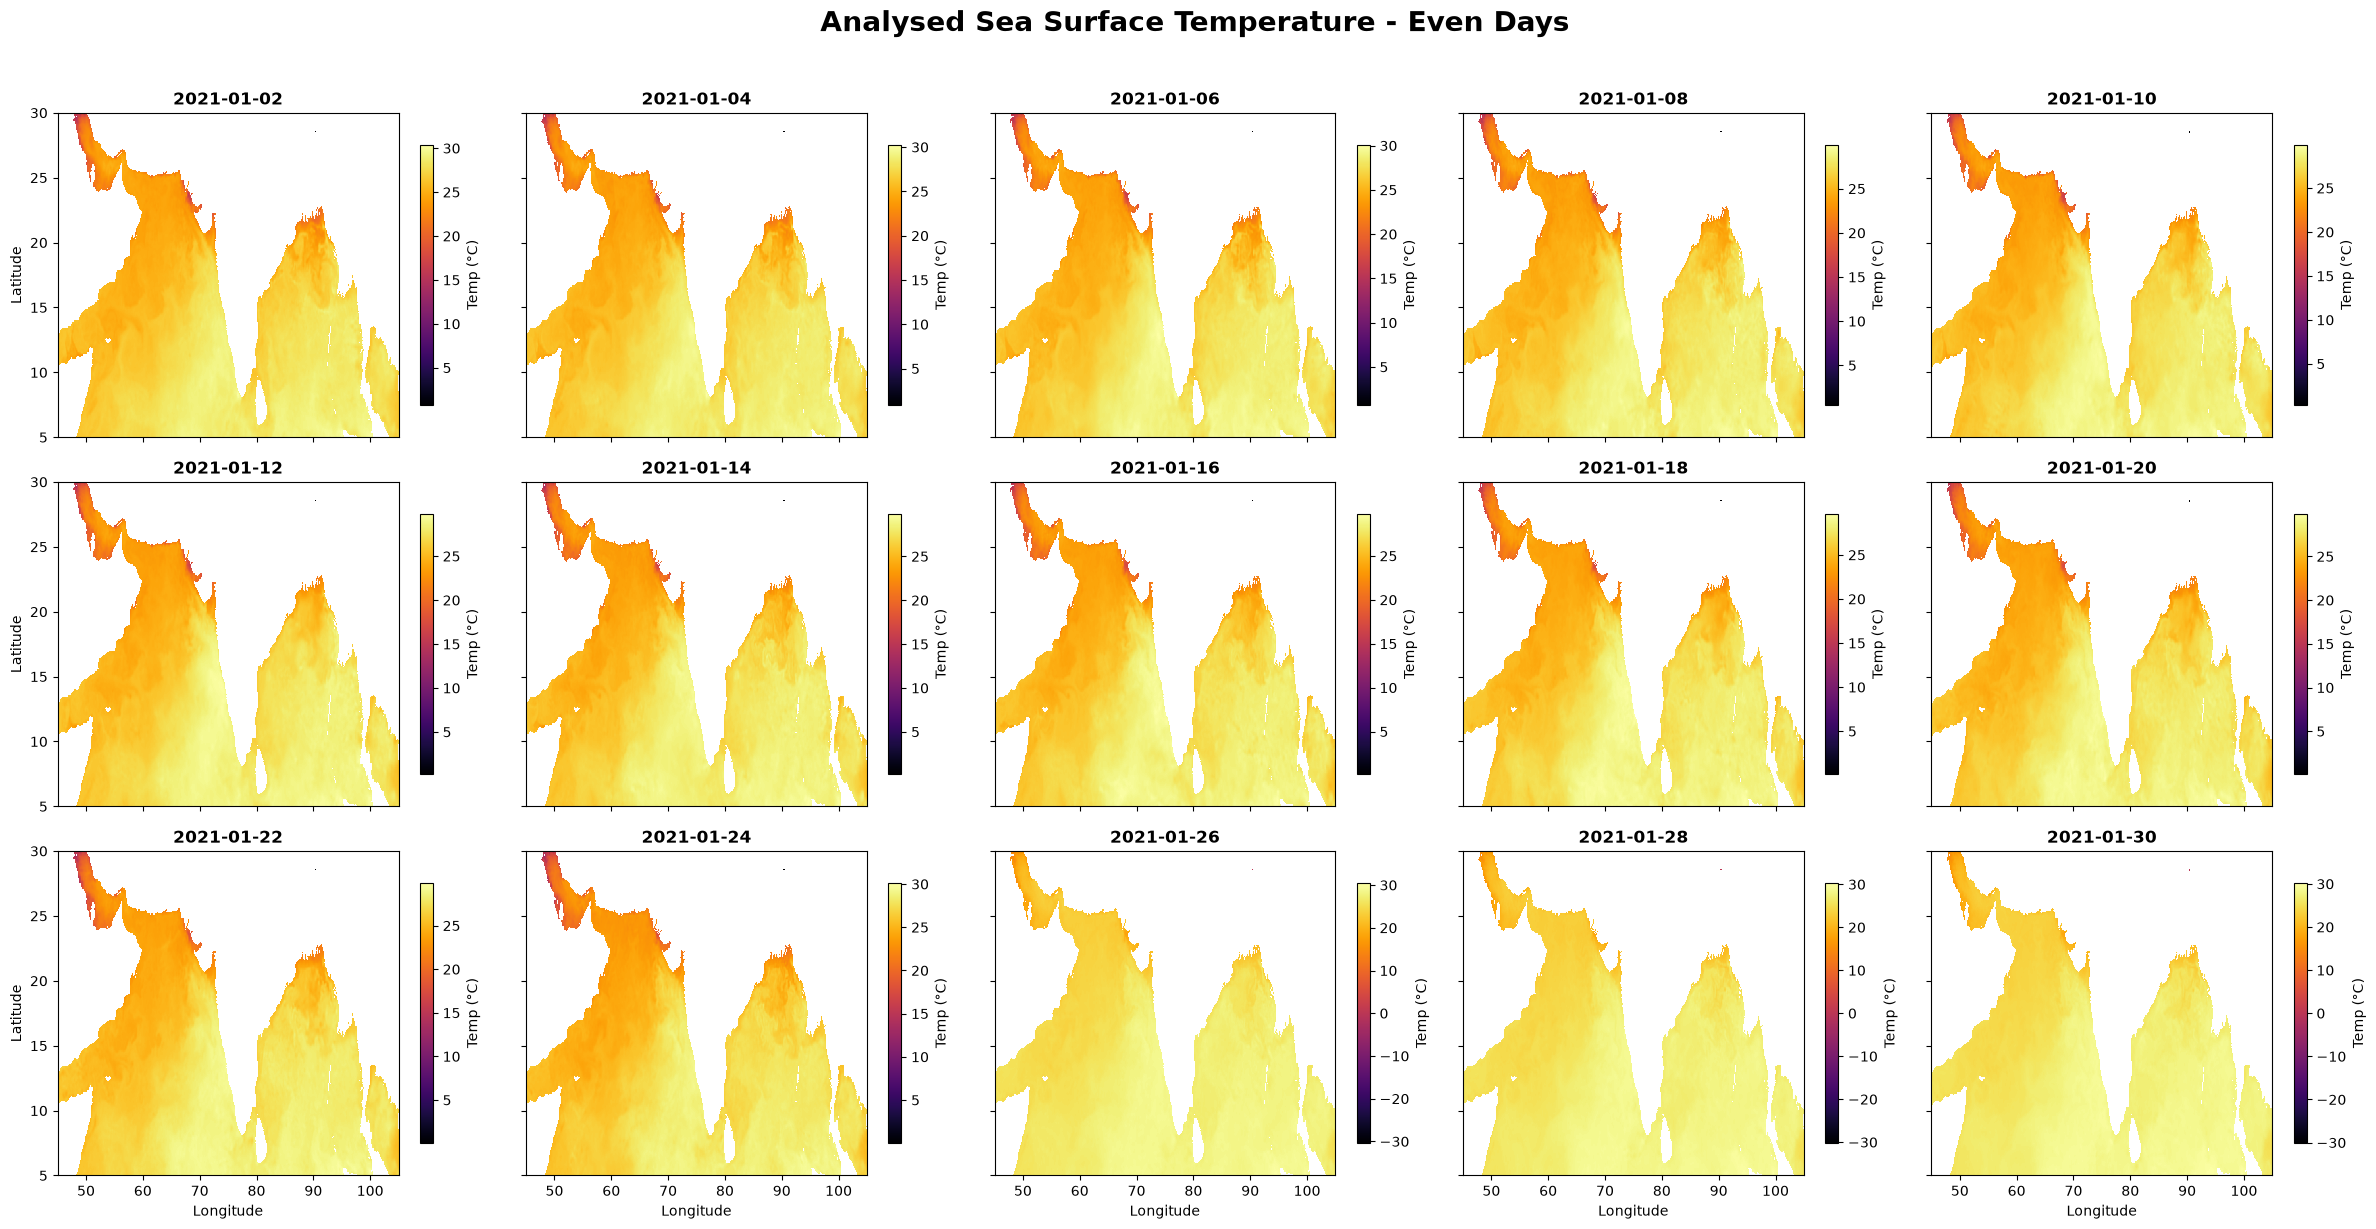

In [12]:
import matplotlib.pyplot as plt
import math

# 1. Automatically filter the dataset for even calendar days (e.g., 2, 4, 6...)
even_ds = ds1.isel(time=(ds1['time'].dt.day % 2 == 0))
total_plots = len(even_ds['time'])

# 2. Setup a dynamic grid (Creates a 3x5 grid for ~15 even days in a month)
cols = 5
rows = math.ceil(total_plots / cols)
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(24, 4 * rows), sharex=True, sharey=True)
axes = axes.flatten()

# 3. Loop through and plot each even day
for i in range(total_plots):
    ax = axes[i]
    
    # Extract data and convert Kelvin to Celsius!
    daily_slice = even_ds['analysed_sst'].isel(time=i) - 273.15
    
    # Extract a clean string of the date (YYYY-MM-DD) for the title
    date_str = str(even_ds['time'].isel(time=i).values)[:10]
    
    # Plot the slice
    daily_slice.plot(
        ax=ax,
        cmap='inferno',
        cbar_kwargs={'shrink': 0.8, 'label': 'Temp (°C)'}
    )
    
    # Formatting
    ax.set_title(f"{date_str}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Longitude" if i >= (rows - 1) * cols else "")
    ax.set_ylabel("Latitude" if i % cols == 0 else "")

# 4. Hide any leftover empty subplots if the grid isn't perfectly filled
for j in range(total_plots, len(axes)):
    axes[j].axis('off')

plt.suptitle("Analysed Sea Surface Temperature - Even Days", fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [1]:
ds2 = xr.open_dataset("inputs_demo/02_jan_sss_.nc")
ds2

NameError: name 'xr' is not defined

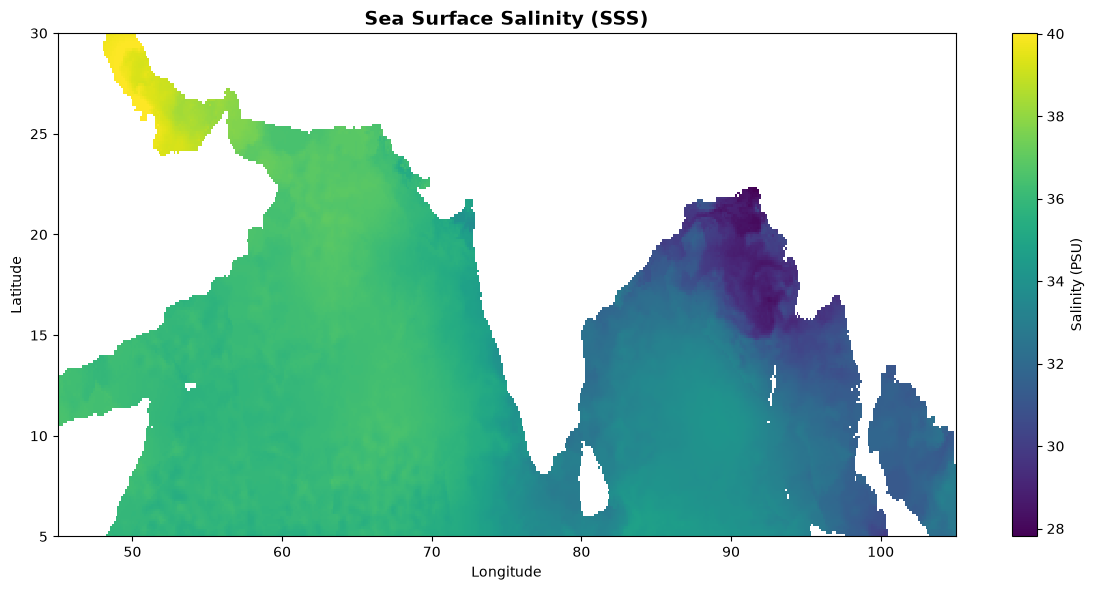

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))

ds2['sos'].isel(time=0, depth=0).plot(
    ax=ax,
    cmap='viridis', 
    cbar_kwargs={'label': 'Salinity (PSU)'}
)

# Formatting
ax.set_title("Sea Surface Salinity (SSS)", fontsize=14, fontweight='bold')
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

In [8]:
import xarray as xr
ds3 = xr.open_dataset("inputs_demo/03_ssh.nc")
ds3

<xarray.Dataset> Size: 771kB
Dimensions:    (time: 1, latitude: 200, longitude: 480)
Coordinates:
  * time       (time) datetime64[ns] 8B 2021-01-01
  * latitude   (latitude) float32 800B 5.062 5.188 5.312 ... 29.69 29.81 29.94
  * longitude  (longitude) float32 2kB 45.06 45.19 45.31 ... 104.7 104.8 104.9
Data variables:
    sla        (time, latitude, longitude) float64 768kB ...
Attributes: (12/43)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    creator_email:                   servicedesk.cmems@mercator-ocean.eu
    ...                              ...
    time_coverage_duration:          P1D
    time_coverage_end:               2023-12-31T12:00:00Z
    time_coverage_resolution:        P1D
    time_coverage_start:             2023-12-30T12:00:00Z
    title:                           DT merged all satellites Global Ocean Gr...
    copernicusmarine_version:        2.4.1

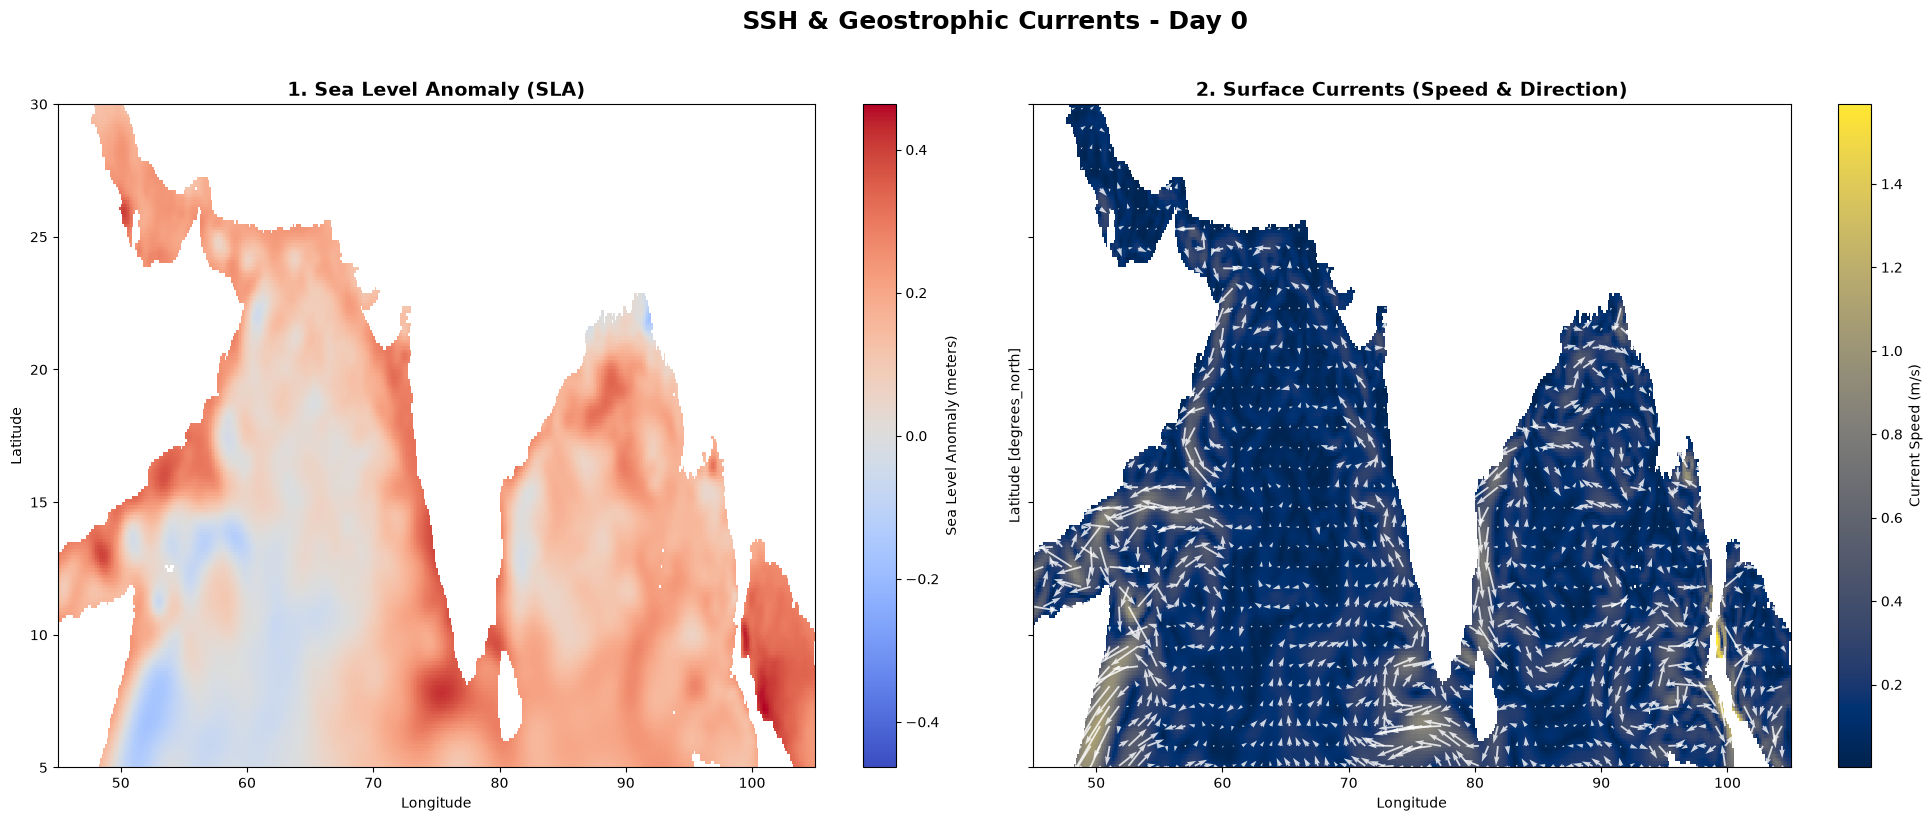

In [19]:
import numpy as np
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8), sharey=True)

# 1. Extract variables for Day 0
sla = ds3['sla'].isel(time=0)
u = ds3['ugosa'].isel(time=0)
v = ds3['vgosa'].isel(time=0)

# 2. Calculate current magnitude (speed) mathematically
speed = np.sqrt(u**2 + v**2)

# --- Subplot 1: Sea Level Anomaly ---
sla.plot(
    ax=axes[0],
    cmap='coolwarm',
    cbar_kwargs={'label': 'Sea Level Anomaly (meters)'}
)
axes[0].set_title("1. Sea Level Anomaly (SLA)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

# --- Subplot 2: Current Speed with Direction Arrows ---
speed.plot(
    ax=axes[1],
    cmap='cividis', # cividis gives great contrast for speeds
    cbar_kwargs={'label': 'Current Speed (m/s)'}
)

# 3. Overlay quiver (arrows) to show the actual flow direction!
# We use a stride of 6 to skip pixels so the map isn't completely black with thousands of arrows
stride = 6
axes[1].quiver(
    u.longitude[::stride], 
    u.latitude[::stride], 
    u[::stride, ::stride], 
    v[::stride, ::stride], 
    color='white', 
    scale=15, 
    alpha=0.8
)

axes[1].set_title("2. Surface Currents (Speed & Direction)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Longitude")

plt.suptitle("SSH & Geostrophic Currents - Day 0", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [3]:
import xarray as xr
ds4 = xr.open_dataset("inputs_demo/04_winds.nc")
ds4

<xarray.Dataset> Size: 24MB
Dimensions:     (valid_time: 124, latitude: 101, longitude: 241)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 992B 2021-01-01 ... 2021-01-31T18...
    expver      (valid_time) <U4 2kB ...
  * latitude    (latitude) float64 808B 30.0 29.75 29.5 29.25 ... 5.5 5.25 5.0
  * longitude   (longitude) float64 2kB 45.0 45.25 45.5 ... 104.5 104.8 105.0
    number      int64 8B ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 12MB ...
    v10         (valid_time, latitude, longitude) float32 12MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-08-29T12:23 GRIB to CDM+CF via cfgrib-0.9.1...

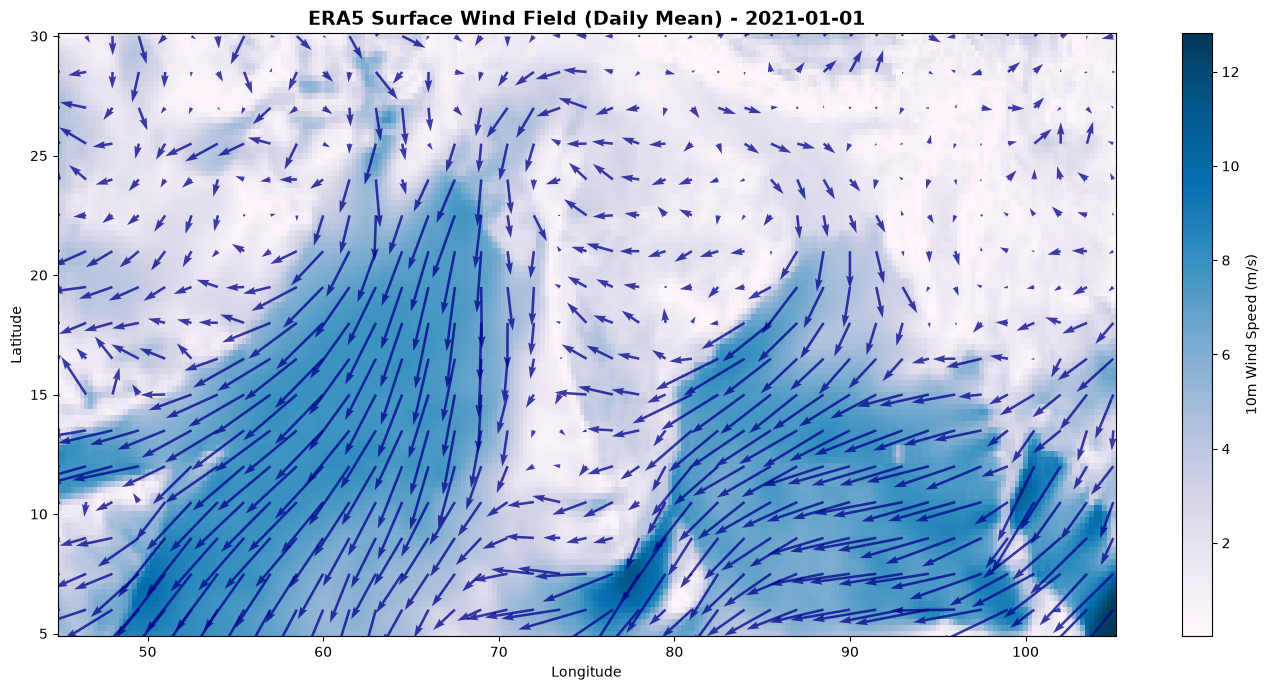

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Resample 6-hourly data to daily mean along 'valid_time'
ds4_daily = ds4.resample(valid_time="1D").mean()

# 2. Extract Day 0 vectors
u = ds4_daily['u10'].isel(valid_time=0)
v = ds4_daily['v10'].isel(valid_time=0)

# Calculate wind speed magnitude (m/s)
speed = np.sqrt(u**2 + v**2)

# 3. Setup figure
fig, ax = plt.subplots(figsize=(14, 7))

# Plot magnitude contour
speed.plot(
    ax=ax,
    cmap='PuBu',
    cbar_kwargs={'label': '10m Wind Speed (m/s)'}
)

# 4. Quiver overlay (skip every 6th grid point for arrow clarity)
stride = 6
ax.quiver(
    u.longitude[::stride],
    u.latitude[::stride],
    u[::stride, ::stride],
    v[::stride, ::stride],
    color='darkblue',
    scale=120,
    alpha=0.75
)

# Formatting
date_str = str(ds4_daily['valid_time'].isel(valid_time=0).values)[:10]
ax.set_title(f"ERA5 Surface Wind Field (Daily Mean) - {date_str}", fontsize=14, fontweight='bold')
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()